In [1]:
%pip install -r requirements.txt

   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.1/11.4 MB 2.6 MB/s eta 0:00:05
   - -------------------------------------- 0.4/11.4 MB 5.0 MB/s eta 0:00:03
   -- ------------------------------------- 0.8/11.4 MB 6.3 MB/s eta 0:00:02
   ---- ----------------------------------- 1.3/11.4 MB 7.4 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/11.4 MB 8.1 MB/s eta 0:00:02
   ------- -------------------------------- 2.1/11.4 MB 8.3 MB/s eta 0:00:02
   -------- ------------------------------- 2.5/11.4 MB 8.5 MB/s eta 0:00:02
   --------- ------------------------------ 2.8/11.4 MB 8.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.9/11.4 MB 7.4 MB/s eta 0:00:02
   ---------- ----------------------------- 3.0/11.4 MB 6.9 MB/s eta 0:00:02
   ----------- ---------------------------- 3.1/11.4 MB 6.5 MB/s eta 0:00:02
   ----------- ---------------------------- 3.3/11.4 MB 6.1 MB/s eta 0:00:02
   ---


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [4]:
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

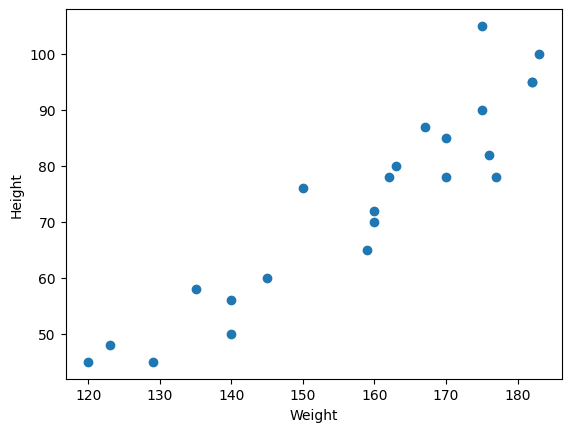

In [5]:
plt.scatter(df['Height'], df['Weight'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [6]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


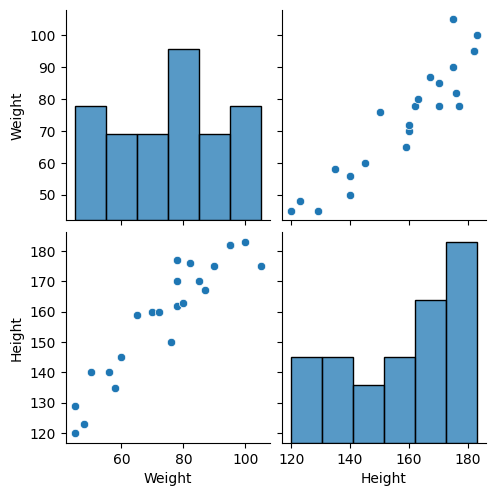

In [7]:
import seaborn as sns
sns.pairplot(df)

In [8]:
X=df[['Weight']]
y=df['Height']

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [11]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [12]:
#Applying Linear Regression
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train, y_train)
regression.coef_


array([17.2982057])

In [13]:
regression.intercept_

np.float64(156.47058823529412)

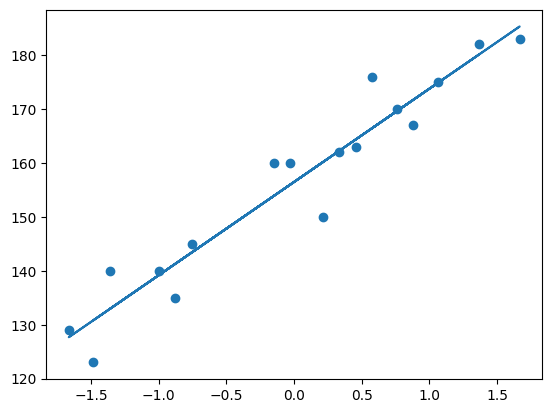

In [14]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

In [15]:
y_pred=regression.predict(X_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [16]:
#performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse=mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print(mse, mae, r2)



114.84069295228699 9.66512588679501 0.7360826717981276


In [17]:
import statsmodels.api as sm
model=sm.OLS(y_train, X_train).fit()
predictions=model.predict(X_test)
print(predictions)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [18]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 27 Sep 2026   Prob (F-statistic):                       0.664
Time:                        14:49:32   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            17.2982     39.138      0.442      0.664     -65.671     100.267
==============================================================================
Omnibus:                        0.135   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.935   Jarque-Bera (JB):                0.203
Skew:                          -0.166   Prob(JB):                        0.904
Kurtosis:                       2.581   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""